# Projet d'Analyse de données



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
#from skimpy import skim
import seaborn as sns 
import prince
from statsmodels.graphics.mosaicplot import mosaic
from pandas.plotting import scatter_matrix

%matplotlib inline

# Introduction


## Prise en charge et présentation du jeu de données 

In [13]:
# Liste des variables originales et leurs descriptions
variables = {
    "Date": "Date du jour de la donnée",
    "Service": "Type de service ou train",
    "Gare de départ": "Gare de départ",
    "Gare d'arrivée": "Gare d'arrivée",
    "Durée moyenne du trajet": "Durée moyenne du trajet",
    "Nombre de circulations prévues": "Nombre de circulations prévues",
    "Nombre de trains annulés": "Nombre de trains annulés",
    "Nombre de trains en retard au départ": "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ": "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ": "Retard moyen de tous les trains au départ",
    "Nombre de trains en retard à l'arrivée": "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée": "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée": "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min": "Nombre de trains en retard entre 15 et 30 min",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "Retard moyen > 15 min si concurrence aérienne",
    "Nombre trains en retard > 30min": "Nombre de trains en retard entre 30 et 60 min",
    "Nombre trains en retard > 60min": "Nombre de trains en retard de plus de 60 min",
    "Prct retard pour causes externes": "Pourcentage de retard pour causes externes",
    "Prct retard pour cause infrastructure": "Pourcentage de retard pour causes infrastructure",
    "Prct retard pour cause gestion trafic": "Pourcentage de retard pour causes gestion trafic",
    "Prct retard pour cause matériel roulant": "Pourcentage de retard pour causes matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "Pourcentage de retard pour causes gestion gare / réutilisation matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence": "Pourcentage de retard pour causes affluence voyageurs"
}

# transformer noms plus courts
short_names = {
    "Date": "date",
    "Service": "service",
    "Gare de départ": "dep_station",
    "Gare d'arrivée": "arr_station",
    "Durée moyenne du trajet": "avg_duration",
    "Nombre de circulations prévues": "planned_trains",
    "Nombre de trains annulés": "cancelled_trains",
    "Nombre de trains en retard au départ": "dep_late_trains",
    "Retard moyen des trains en retard au départ": "dep_avg_late",
    "Retard moyen de tous les trains au départ": "dep_avg_all",
    "Nombre de trains en retard à l'arrivée": "arr_late_trains",
    "Retard moyen des trains en retard à l'arrivée": "arr_avg_late",
    "Retard moyen de tous les trains à l'arrivée": "arr_avg_all",
    "Nombre trains en retard > 15min": "late_15",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "late_15_air",
    "Nombre trains en retard > 30min": "late_30",
    "Nombre trains en retard > 60min": "late_60",
    "Prct retard pour causes externes": "pct_external",
    "Prct retard pour cause infrastructure": "pct_infra",
    "Prct retard pour cause gestion trafic": "pct_traffic",
    "Prct retard pour cause matériel roulant": "pct_rolling",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "pct_station",
    "Prct retard pour cause prise en compte voyageurs (affluence": "pct_passengers"
}

# création DataFrame pour affichage 
df_vars = pd.DataFrame({
    "Variables renommées": [short_names[k] for k in variables.keys()],
    "Description": [variables[k] for k in variables.keys()]
})

print("Chaque individu représente un mois, pour lesquels on observe 23 variables")
display(df_vars.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left')])]
))


Chaque individu représente un mois, pour lesquels on observe 23 variables


,Variables renommées,Description
0,date,Date du jour de la donnée
1,service,Type de service ou train
2,dep_station,Gare de départ
3,arr_station,Gare d'arrivée
4,avg_duration,Durée moyenne du trajet
5,planned_trains,Nombre de circulations prévues
6,cancelled_trains,Nombre de trains annulés
7,dep_late_trains,Nombre de trains en retard au départ
8,dep_avg_late,Retard moyen des trains en retard au départ
9,dep_avg_all,Retard moyen de tous les trains au départ


## Création des data sets

In [15]:
data = pd.read_excel('regularite-mensuelle-tgv-aqst.ods',engine='odf')
data = data.rename(columns=short_names)

display( 
    data.head().style.background_gradient(cmap='BuPu')
)

C:\Users\clara\anaconda3\Lib\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
C:\Users\clara\anaconda3\Lib\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,Commentaire annulations,dep_late_trains,dep_avg_late,dep_avg_all,Commentaire retards au départ,arr_late_trains,arr_avg_late,arr_avg_all,Commentaire retards à l'arrivée,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,gestions PSH,correspondances)
0,2025-01,International,GENEVE,PARIS LYON,193,238,1,nan,216,3.182485,2.979606,nan,19,42.776316,4.399015,nan,19,42.776316,0,13,10.000000,60.000000,20.000000,5.000000,5.000000,0.000000,nan,nan
1,2025-01,International,ITALIE,PARIS LYON,535,30,0,nan,14,2.713095,1.366667,nan,5,31.940000,8.500556,nan,5,31.940000,0,1,20.000000,0.000000,40.000000,40.000000,0.000000,0.000000,nan,nan
2,2025-01,National,BESANCON FRANCHE COMTE TGV,PARIS LYON,133,183,0,nan,30,17.588889,2.555373,nan,24,52.936111,6.397359,nan,20,60.764167,0,14,20.000000,48.000000,16.000000,12.000000,0.000000,4.000000,nan,nan
3,2025-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,145,1029,0,nan,317,18.564090,5.589828,nan,180,40.713704,8.774603,nan,132,50.812500,0,69,20.000000,20.555556,29.444444,16.111111,6.111111,7.777778,nan,nan
4,2025-01,National,BREST,PARIS MONTPARNASSE,232,294,7,nan,20,11.966667,0.835714,nan,30,37.223889,4.704413,nan,30,37.223889,0,13,32.258065,25.806452,16.129032,9.677419,9.677419,6.451613,nan,nan


In [16]:
data['moy_retard_train_deja_retard'] = np.where(
    data['dep_late_trains'] > 0, 
    (data['dep_avg_all'] * data['planned_trains']) / data['dep_late_trains'], 
    0  # Valeur par défaut si aucun train n'est en retard
)

In [17]:
data.dtypes

date                                object
service                             object
dep_station                         object
arr_station                         object
avg_duration                         int64
planned_trains                       int64
cancelled_trains                     int64
Commentaire annulations            float64
dep_late_trains                      int64
dep_avg_late                       float64
dep_avg_all                        float64
Commentaire retards au départ      float64
arr_late_trains                      int64
arr_avg_late                       float64
arr_avg_all                        float64
Commentaire retards à l'arrivée    float64
late_15                              int64
late_15_air                        float64
late_30                              int64
late_60                              int64
pct_external                       float64
pct_infra                          float64
pct_traffic                        float64
pct_rolling

In [18]:
cols_to_drop = [
    c for c in data.columns 
    if c.startswith("Commentaire") 
    or " gestions PSH" in c 
    or "correspondances)" in c
]
data = data.drop(columns=cols_to_drop)
display(
    data.head().style.background_gradient(cmap="BuPu")
)
len(data)

data['date'] = data['date'].astype('category')
data['service'] = data['service'].astype('category')
data['dep_station'] = data['dep_station'].astype('category')
data['arr_station'] = data['arr_station'].astype('category')
skim(data)

,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,arr_late_trains,arr_avg_late,arr_avg_all,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,moy_retard_train_deja_retard
0,2025-01,International,GENEVE,PARIS LYON,193,238,1,216,3.182485,2.979606,19,42.776316,4.399015,19,42.776316,0,13,10.000000,60.000000,20.000000,5.000000,5.000000,0.000000,3.283085
1,2025-01,International,ITALIE,PARIS LYON,535,30,0,14,2.713095,1.366667,5,31.940000,8.500556,5,31.940000,0,1,20.000000,0.000000,40.000000,40.000000,0.000000,0.000000,2.928571
2,2025-01,National,BESANCON FRANCHE COMTE TGV,PARIS LYON,133,183,0,30,17.588889,2.555373,24,52.936111,6.397359,20,60.764167,0,14,20.000000,48.000000,16.000000,12.000000,0.000000,4.000000,15.587778
3,2025-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,145,1029,0,317,18.564090,5.589828,180,40.713704,8.774603,132,50.812500,0,69,20.000000,20.555556,29.444444,16.111111,6.111111,7.777778,18.144900
4,2025-01,National,BREST,PARIS MONTPARNASSE,232,294,7,20,11.966667,0.835714,30,37.223889,4.704413,30,37.223889,0,13,32.258065,25.806452,16.129032,9.677419,9.677419,6.451613,12.285000


NameError: name 'skim' is not defined

In [ ]:
data_num = data.select_dtypes(include="number")
data_qual = data.select_dtypes(include=["object", "category"])

# Réduction de dimension linéaire

## Qu'est ce qui pourrait, dans les variables qualitatives, expliquer le retard ? - MCA

Nos individus sont très déterminés par des variables qualitatives (Gare de départ, gare d'arrivée ...). Nous allons donc utiliser la MCA pour étudier les données.

Nous allons tenter de répondre à la question suivte : "Est-ce qu'on peut expliquer le retard 'un train en fonction de la date, du service, de la gare de départ et/ou de la gare d'arrivée ?"

Pour cela nous allons créer une variable qualitative prenant pour valeur 'Jamais', 'Rarement', 'Régulièrement', 'Souvent' en fonction de la proportion de retard sur une liaison et sur un mois.

In [ ]:
proportion_retard = (data['arr_late_trains']+data['cancelled_trains']) / data['planned_trains']

bins = [-0.01, 0.05, 0.15, 0.40, 1.0]
labels = ['Jamais', 'Rarement', 'Régulièrement', 'Souvent']

data['retard'] = pd.cut(proportion_retard, bins=bins, labels=labels)

print(data['retard'].value_counts())

In [ ]:
df_mca=data.select_dtypes(include='category')
display(df_mca.head())

In [ ]:
plt.figure(figsize=(14, 8))
mosaic(df_mca, ['date', 'retard'], 
       title='Proportion de retard par mois',
       labelizer=lambda k: "")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le mois pour lequel il y a le plus de retard est le mois de juillet.

In [ ]:
X = df_mca[['service', 'dep_station', 'arr_station']]

mca = prince.MCA(
    n_components=3,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mca = mca.fit(X)

mca.eigenvalues_summary

In [ ]:
mca.column_contributions_.T.style.background_gradient(cmap='YlOrRd', axis=1).format('{:.0%}')

On peut voir que c'est principalement la variable service_International qui contribut à l'axe 0, la variable dep_station_PARIS qui contribut à l'axe 1 et les variables arr_station_PARIS LYON et dep_station_PARIS LYON qui contribuent à l'axe 2.

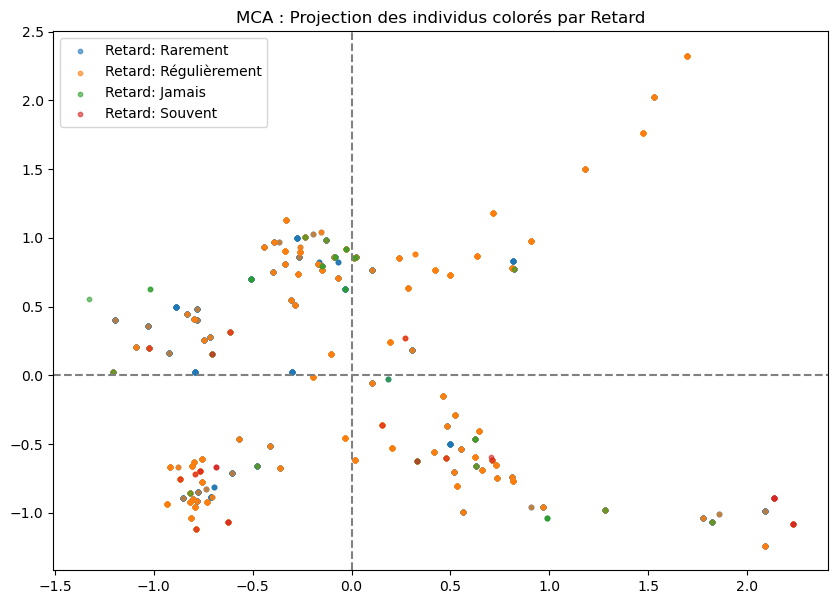

In [57]:
# Obtenir les coordonnées des lignes (individus)
row_coordinates = mca.row_coordinates(X)

# Tracer le graphique
plt.figure(figsize=(10, 7))
for val in df_mca['retard'].unique():
    mask = df_mca['retard'] == val
    plt.scatter(
        row_coordinates.loc[mask, 1], 
        row_coordinates.loc[mask, 2], 
        label=f"Retard: {val}",
        alpha=0.6,
        s=10
    )

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.title("MCA : Projection des individus colorés par Retard")
plt.legend()
plt.show()

On remarque que les resultats de cette analyse ne sont pas interprétables.

**Demender quoi faire aux profs avec ça !**

## Qu'est ce qui pourrait, dans les variables qualitatives, expliquer le retard ? - ACP

Dans cette partie on va essayer d'expliquer la proportion de retard d'une autre manière. Pour se faire nous allons construire un plan ACP avec les variables quantitatives (hors pourcentages) et essayer de trouver des éléments qui expliqueraient le retard.

In [ ]:
var_pca=["avg_duration", "planned_trains", "cancelled_trains", "dep_late_trains", "dep_avg_late", "dep_avg_all", "arr_avg_late", "arr_avg_all", "late_15", "late_15_air", "late_30", "late_60"]
df_pca = data[var_pca]
display(df_pca.head())

# EST CE QUE IL FAUDRAIT PAS AJOUTER LA VAR QU'ON A CREE late_5 ????

In [ ]:
pca = prince.PCA(
    n_components=10,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

pca = pca.fit(df_pca)

display(pca.eigenvalues_summary)

In [ ]:
explained_variance_ratio = pca.eigenvalues_summary['% of variance'].str.replace('%', '').astype(float)
n_bars = 10

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scree plot
sns.barplot(x=np.arange(1, n_bars + 1), y=explained_variance_ratio[:n_bars],
            color="coral", ax=axes[0])
axes[0].set_xlabel("Composantes")
axes[0].set_ylabel("Variance expliquée (%)")
axes[0].set_title("Scree plot")
axes[0].spines[["top", "right"]].set_visible(False)

# Cumulative explained variance
cumvar = np.cumsum(explained_variance_ratio)
axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, color="coral", linewidth=2)
axes[1].axhline(90, color="gray", linestyle="--", linewidth=1, label="90%")
axes[1].axvline(3, color="steelblue", linestyle="--", linewidth=1, label="3 composantes")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance expliquée cumulative (%)")
axes[1].set_title("Variance expliquée")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Variance expliquée par les 3 premières componsantes : {cumvar[2]:.2f}%")

On remarque que la variance est mal expliquée par les premières composantes principales. On va choisir de représenter les 3 premières, tout en sachant qu'il faudra mettre en perspectives les resultats vu que seulement 65.63% de la variance sera expliquée.

In [ ]:
var_correlations = pca.column_correlations
coords = pca.row_coordinates(df_pca)
retard_col = data.loc[df_pca.index, 'retard']
pairs = [(0, 1), (0, 2), (1, 2)]
palette_retard = {'Jamais':'green', 'Rarement':'yellow', 'Régulièrement':'orange', 'Souvent': 'red'}

fig, axes = plt.subplots(2, 3, figsize=(22, 12), gridspec_kw={'height_ratios': [1.5, 1]})

for i, (dim_x, dim_y) in enumerate(pairs):
    ax_circle = axes[0, i]
    circle = plt.Circle((0,0), 1, color='lightgrey', fill=False, linestyle='--')
    ax_circle.add_artist(circle)
    
    for col in var_correlations.index:
        x = var_correlations.loc[col, dim_x]
        y = var_correlations.loc[col, dim_y]
        ax_circle.arrow(0, 0, x, y, color='r', alpha=0.4, head_width=0.05)
        ax_circle.text(x*1.15, y*1.15, col, color='black', ha='center', va='center', fontsize=9, fontweight='bold')

    ax_circle.set_xlim(-1.3, 1.3)
    ax_circle.set_ylim(-1.3, 1.3)
    ax_circle.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax_circle.axvline(0, color='grey', linestyle='--', alpha=0.5)
    
    var_x = pca.eigenvalues_summary.loc[dim_x, '% of variance']
    var_y = pca.eigenvalues_summary.loc[dim_y, '% of variance']
    
    ax_circle.set_title(f"Cercle : Plan {dim_x} x {dim_y}")
    ax_circle.set_xlabel(f"Dim {dim_x} ({var_x})")
    ax_circle.set_ylabel(f"Dim {dim_y} ({var_y})")
    ax_circle.set_aspect('equal')

    ax_proj = axes[1, i]
    sns.scatterplot(
        x=coords[dim_x], 
        y=coords[dim_y], 
        hue=retard_col, 
        palette=palette_retard,
        hue_order=['Jamais', 'Rarement', 'Régulièrement', 'Souvent'],
        alpha=0.5, 
        s=30, 
        ax=ax_proj
    )
    ax_proj.set_title(f"Projection : Plan {dim_x} x {dim_y}")
    ax_proj.set_xlabel(f"Dim {dim_x} ({var_x})")
    ax_proj.set_ylabel(f"Dim {dim_y} ({var_y})")
    ax_proj.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax_proj.axvline(0, color='grey', linestyle='--', alpha=0.5)
    ax_proj.legend(title='Fréquence Retard', loc='upper right', fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("PCA Complète : Variables (haut) vs Trajets (bas)", fontsize=20, fontweight='bold')
plt.show()

**Faire interprétation, j'ai le cerveau embrummé**

# Méthodes de clustering

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import colors

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

Dans cette partie, nous allons chercher à répondre à la question : **la réduction de dimension avec la PCA conserve-t-elle la structure des données utile au clustering ?**

Dans un premier temps, nous allons faire du clustering sur les données de la PCA.

PS : Nous avons choisi de ne pas traiter l'algorithme DBSCAN, car en pratique il ne donne pas de bon résultats. 

# 1. Méthode des k-means

### Sélection du nombre de clusters

### 1. Méthode du coude

La méthode du coude permet de choisir le nombre de clusters k dans k-means en traçant l’erreur WCSS en fonction du nombre de clusters.
Quand le nombre de cluster augmente, l’erreur diminue rapidement puis ralentit. On choisit donc k au point où la courbe “fait un coude”, c’est-à-dire quand ajouter des clusters n’apporte presque plus d’amélioration.

In [85]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto",
                    max_iter=100, random_state=42)
    inertia.append(kmeans.fit(df_pca).inertia_)

inertia = np.array(inertia)

# --- #

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(2, 11), inertia[1:], marker="o", color="steelblue",
        linewidth=2, markersize=6)

ax.set_xlabel("Number of clusters")
ax.set_ylabel("Inertia")
ax.set_title("Elbow method — K-means")
ax.set_xticks(range(2, 11))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


# --- #


# Using yellowbrick

kmeans = KMeans(init='k-means++', n_init='auto', max_iter=100, random_state=42)
visualizer = KElbowVisualizer(kmeans, k=(4,12), force_model=True)

visualizer.fit(df_pca)    # Fit the data to the visualizer
visualizer.show()    # Finalize and render the figure

NameError: name 'df_pca' is not defined

Sur le premier graphe, on n'observe pas un "coude" franc. On pourrait choisr entre 4 et 6 clusters. Alors, sur le deuxième graphe, on trace la ligne verte représente le temps d'exécution. Cela peut aider à faire un choix, ici k=7, mais le choix n'est pas très évident. De plus, il n'y a rien dans le contexte des données qui nous indiquerai un nombre de clusters logique.
Nous allons donc regarder le score silhouette.

### 2. Méthode du score silhouette

La méthode du score de silhouette permet également de choisir le nombre de clusters k, en mesurant à quel point les points sont bien regroupés dans leur cluster.
Il varie entre −1 et 1 : plus il est proche de 1, plus les clusters sont bien séparés; plus il est proche de 0, plus les clusters se chevauchent; et s'il est négatif, le clustering est mauvais. C’est une méthode plus objective que le coude pour évaluer la qualité du clustering.

On calcule ce score pour plusieurs valeurs de k et on choisit celui qui maximise le score moyen.

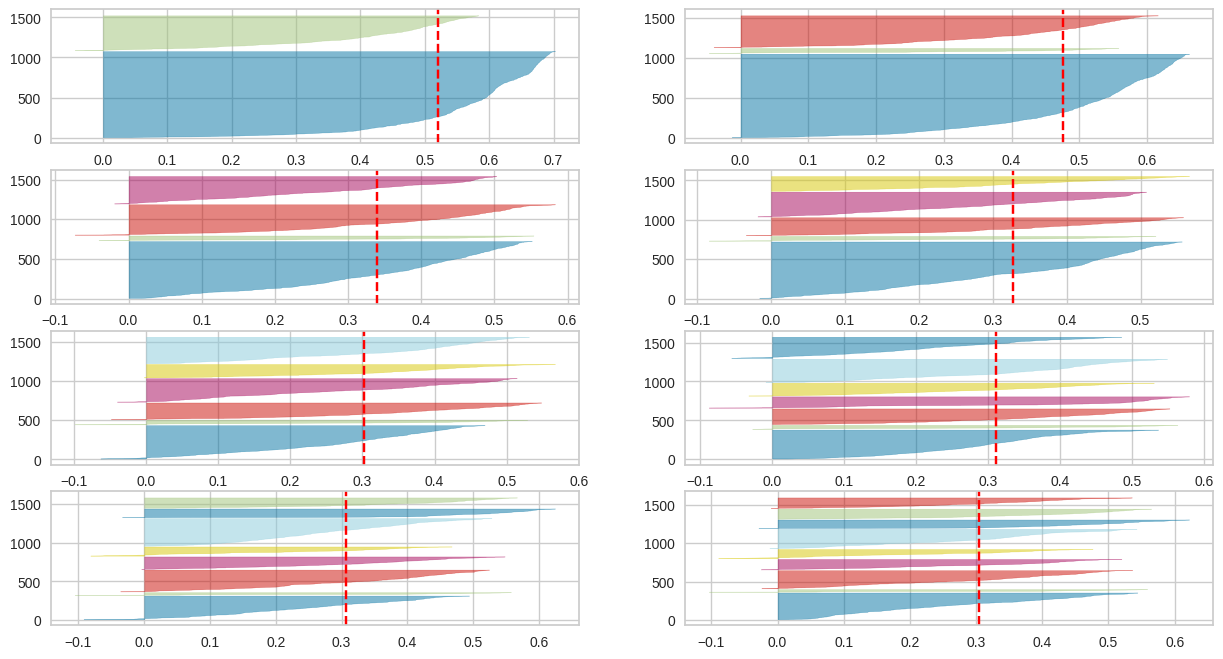

In [28]:
fig, ax = plt.subplots(4, 2, figsize=(15,8))

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=100, random_state=42)
    q, mod = divmod(k, 2)
    
    # Create SilhouetteVisualizer instance with KMeans instance
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax[q-1][mod], force_model=True)
    visualizer.fit(df_pca)

Le score moyen le plus haut est obtenu pour 2 clusters. De plus, il y a peu de valuers négatives.
On va donc décider de prendre **2 clusters**.

### Clustering avec le K trouvé : K=2

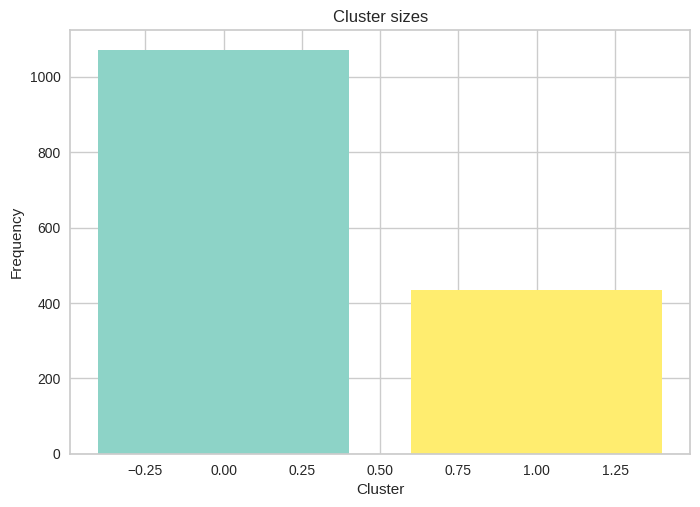

In [29]:
K = 2

kmeans_pca = KMeans(n_clusters=K, init='k-means++', n_init='auto', random_state=0)
clusters_pca = kmeans_pca.fit_predict(df_pca)


cmap = plt.get_cmap('Set3',K)
plt.bar(*np.unique(clusters_pca, return_counts=True), color=cmap.colors)
plt.ylabel("Frequency")
plt.xlabel("Cluster")
plt.title("Cluster sizes")
plt.show()

/tmp/ipykernel_19494/1678787016.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(coords.iloc[:, 0], coords.iloc[:, 1],


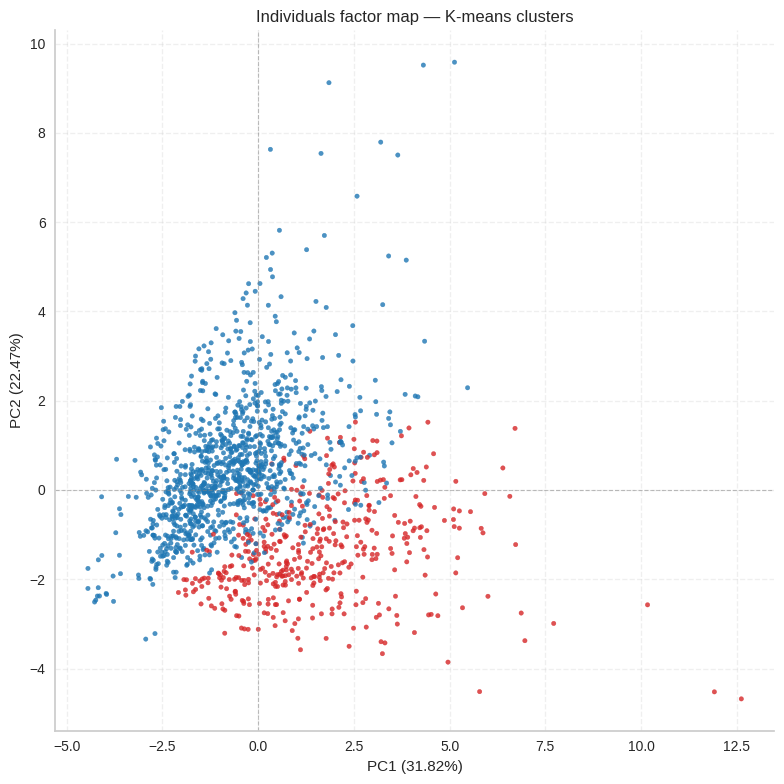

In [30]:
coords = pca.transform(df_pca)
colors = ["#1f77b4", "#d62728"] #bleu et rouge

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(coords.iloc[:, 0], coords.iloc[:, 1],
                c=[colors[i] for i in clusters_pca], s=10, alpha=0.8, cmap=cmap)

ax.set_title("Individuals factor map — K-means clusters")

ax.set_xlabel(f"PC1 ({pca.eigenvalues_summary.loc[0, '% of variance']})")
ax.set_ylabel(f"PC2 ({pca.eigenvalues_summary.loc[1, '% of variance']})")

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

#fig.colorbar(sc, ax=ax, ticks=range(K), label="Cluster")

plt.tight_layout()
plt.show()


**Conclusion clustering sur PCA :**
On n'observe pas des clusters bien distincts, il est difficile de tirer des conclusions.  

Maintenant nous allons faire ce clustering sur les données complètes (sans avoir fait la PCA) et comparer avec celui ci-dessus.

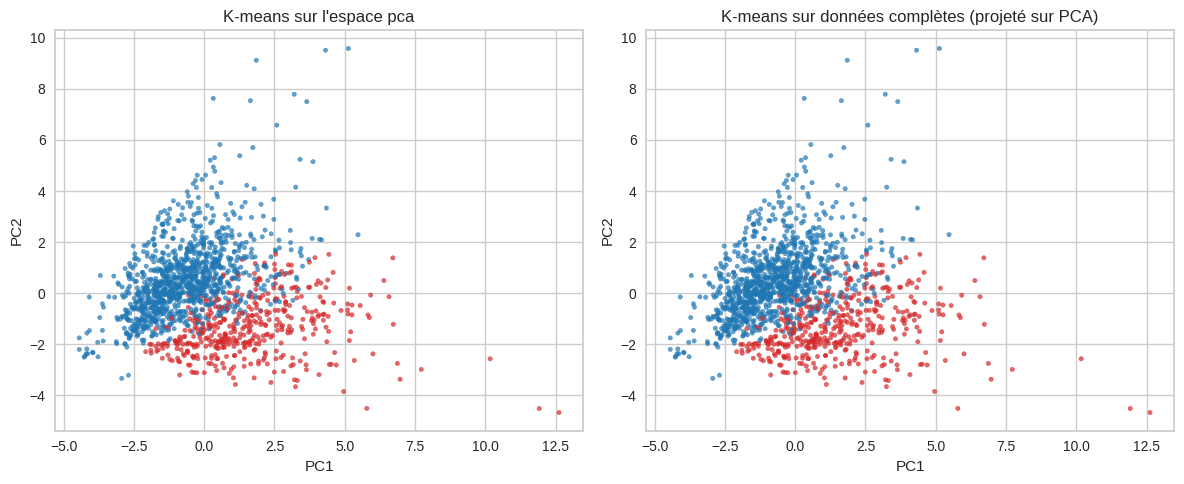

In [38]:
kmeans_full = KMeans(n_clusters=K, init="k-means++", n_init="auto", random_state=0)
clusters_full = kmeans_full.fit_predict(data_num)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#1f77b4", "#d62728"]

# --- PCA clustering ---
axes[0].scatter(coords.iloc[:, 0], coords.iloc[:, 1],
                c=[colors[i] for i in clusters_pca],
                s=10, alpha=0.7)

axes[0].set_title("K-means sur l'espace pca")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# --- FULL clustering projeté sur PCA ---
axes[1].scatter(coords.iloc[:, 0], coords.iloc[:, 1],
                c=[colors[i] for i in clusters_full],
                s=10, alpha=0.7)

axes[1].set_title("K-means sur données complètes (projeté sur PCA)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

Les résultats de clustering obtenus après PCA sont similaires à ceux obtenus sur les données complètes. Cela suggère que la réduction de dimension conserve l’essentiel de la structure pertinente pour le clustering. Pour vérifier, on va comparer les scores silhouette. 

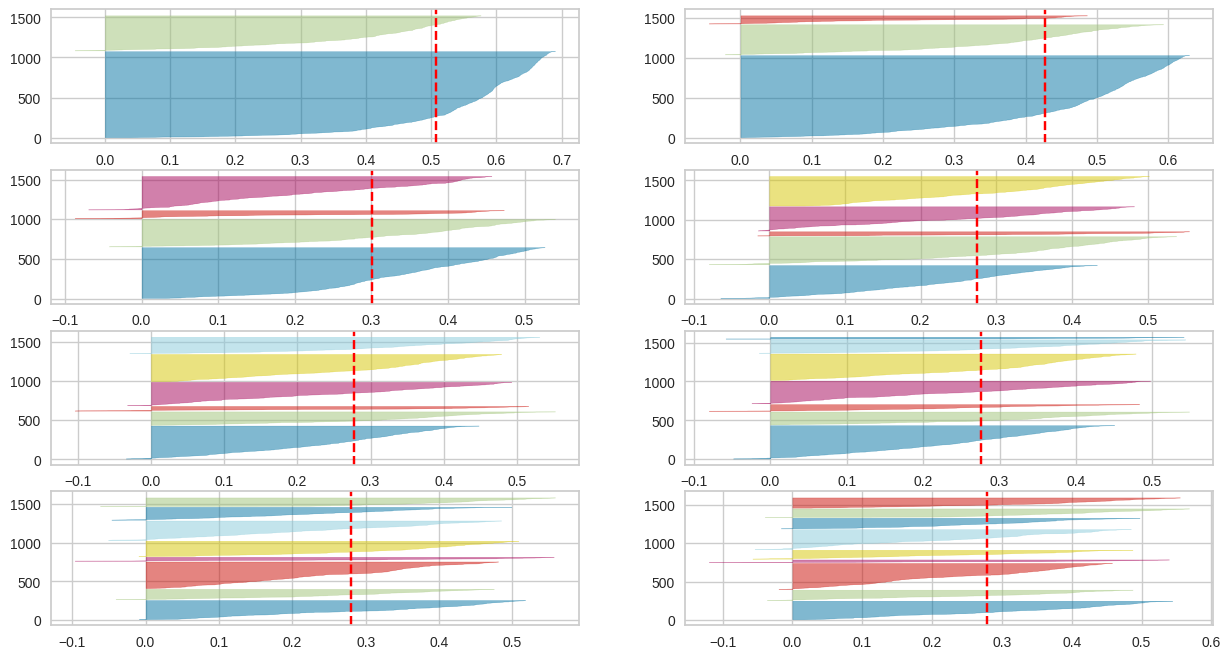

In [39]:
fig, ax = plt.subplots(4, 2, figsize=(15,8))

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=100, random_state=42)
    q, mod = divmod(k, 2)
    
    # Create SilhouetteVisualizer instance with KMeans instance
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax[q-1][mod], force_model=True)
    visualizer.fit(data_num)

Le score moyen le plus haut est aussi obtenu pour 2 clusters. Il est à peine inférieur à celui calculé sur les données après PCA. Les scores silhouette sont globalement comparables.

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#### Matrice de confusion

La matrice de confusion permet d’évaluer la qualité d’un modèle de classification en comparant les vraies classes et les classes prédites par le modèle. 

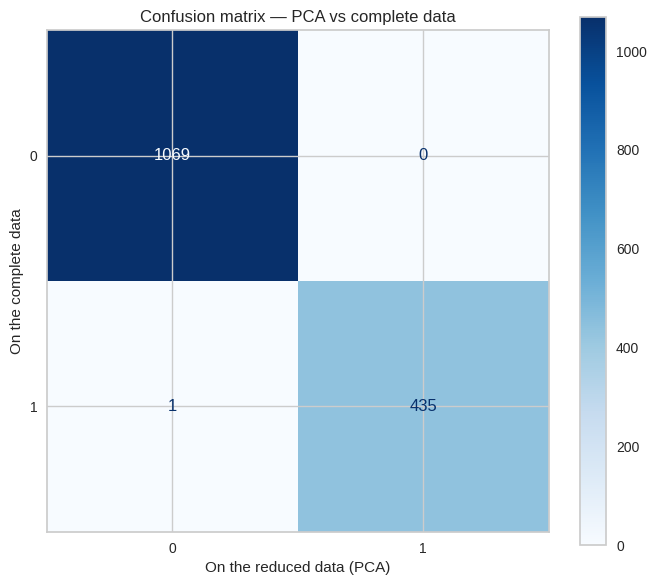

In [42]:
K=2

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(confusion_matrix(clusters_full, clusters_pca)).plot(
    ax=ax, colorbar=True, cmap="Blues"
)

ax.set_xlabel("On the reduced data (PCA)")
ax.set_ylabel("On the complete data")
ax.set_title("Confusion matrix — PCA vs complete data")

plt.tight_layout()
plt.show()

Sur la diagonale, les cases bleues comptent de nombres de points bien classés. 
Ici, en faisant du clustering sur après la PCA, un seul point est mal placé.

On peut conclure que **la PCA a conservé la structure de clustering** (attention cela ne veut pas dire qu’il n’y a aucune perte d’information).

Nous allons maintenant tester plusieurs méthodes de clustering pour éviter de tirer des conclusions basées sur un seul modèle (potentiellement pas adapté).

# 2. Méthode des Hierarchical Agglomerative Clustering (HAC)

Le Hierarchical Agglomerative Clustering est une méthode de clustering qui commence avec chaque point comme un cluster, puis fusionne progressivement les clusters les plus proches grâce à des liaisons (critères de distance entre clusters), jusqu’à obtenir une structure finale. On peut représenter ce processus avec un dendrogramme, et choisir le nombre de clusters en “coupant” l’arbre à un certain niveau.

In [45]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

De la même façon que précédemment, nous allons essayer de choisir le nombre de clusters optimal pour cette méthode de clustering.

### Sélection du nombre de clusters

###  Méthode du coude

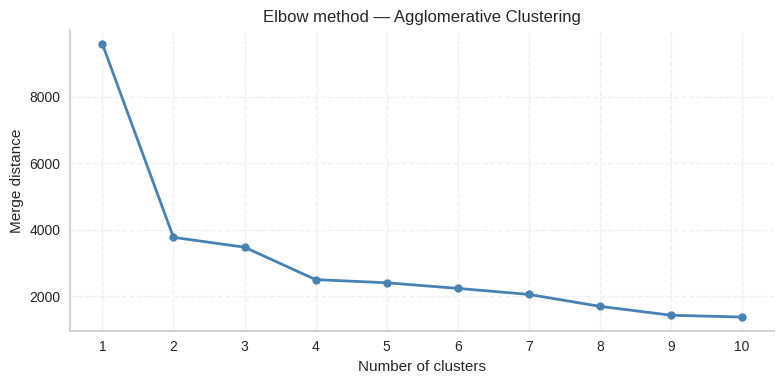

In [46]:
ac = AgglomerativeClustering(linkage="ward", compute_distances=True)
ac.fit(data_num)

n_sizes = 10
x = np.arange(n_sizes, 0, -1)
y = ac.distances_[-n_sizes:]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y, marker="o", color="steelblue", linewidth=2, markersize=6)

ax.set_xlabel("Number of clusters")
ax.set_ylabel("Merge distance")
ax.set_title("Elbow method — Agglomerative Clustering")
ax.set_xticks(x)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

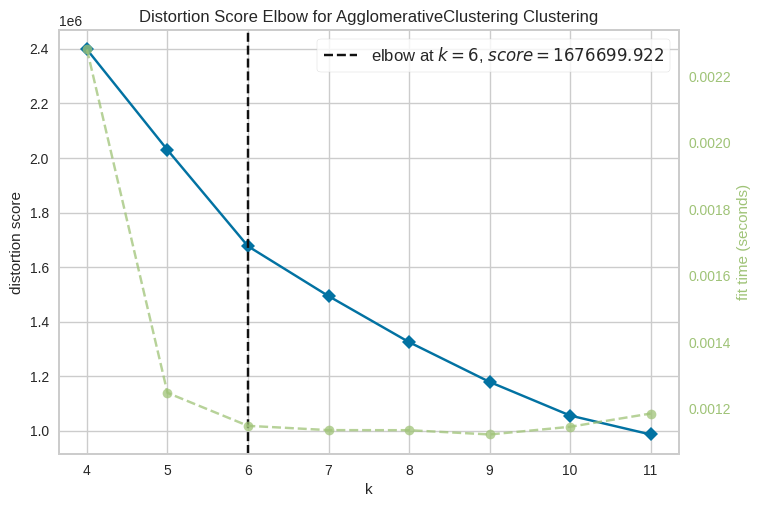

In [94]:
ac = AgglomerativeClustering(linkage='ward', compute_distances=True)
visualizer = KElbowVisualizer(ac, k=(4,12), force_model=True)

visualizer.fit(data_reduced_samples)  # Fit the data to the visualizer
visualizer.show()   
plt.show()

La méthode du coude nous invite à chosir 2 clusters. 

EST CE QUE JE LAISSE LE DEUXIEME GRAPHE SACHANT QUE LE PREMIER EST DEJA PAS MAL EXPLICITE;

Nous représentons le dendrogramme pour chaque type de liaison.

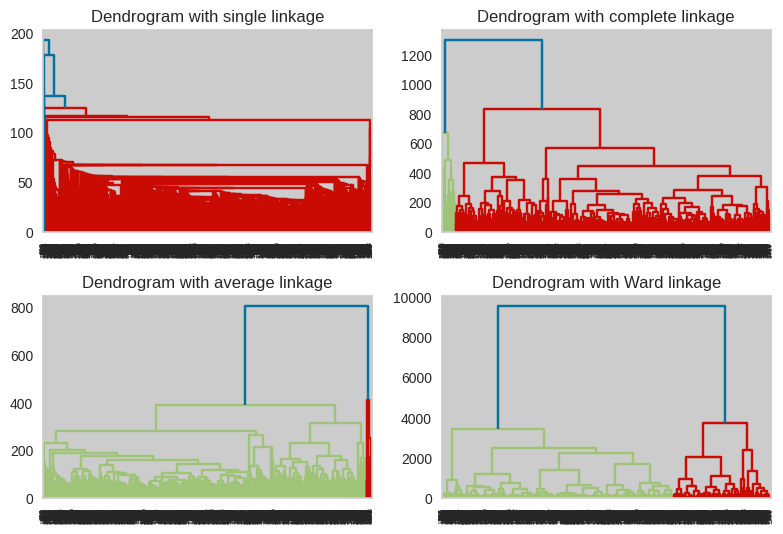

In [50]:
plt.subplot(2,2,1)
linkage_matrix_single = sch.linkage(data_num, method='single')
sch.dendrogram(linkage_matrix_single)
plt.title("Dendrogram with single linkage")

plt.subplot(2,2,2)
linkage_matrix_complete = sch.linkage(data_num, method='complete')
sch.dendrogram(linkage_matrix_complete)
plt.title("Dendrogram with complete linkage")

plt.subplot(2,2,3)
linkage_matrix_average = sch.linkage(data_num, method='average')
sch.dendrogram(linkage_matrix_average)
plt.title("Dendrogram with average linkage")

plt.subplot(2,2,4)
linkage_matrix_ward = sch.linkage(data_num, method='ward')
sch.dendrogram(linkage_matrix_ward)
plt.title("Dendrogram with Ward linkage")

plt.tight_layout()
plt.show()

Selon la méthode de liaison utilisée, la structure des clusters varie fortement dans le cadre du HAC.
La méthode **single linkage** tend à produire un effet de chaînage avec des clusters allongés, tandis que **average linkage** donne des résultats plus intermédiaires.
La méthode de **Ward**, qui minimise la variance intra-cluster, produit généralement des clusters plus compacts et bien séparés.
Il n’existe pas de méthode optimale universelle, mais Ward semble ici fournir la structure la plus cohérente visuellement.

Comme précédemment, on aurait tendance à choisir 2 clusters.

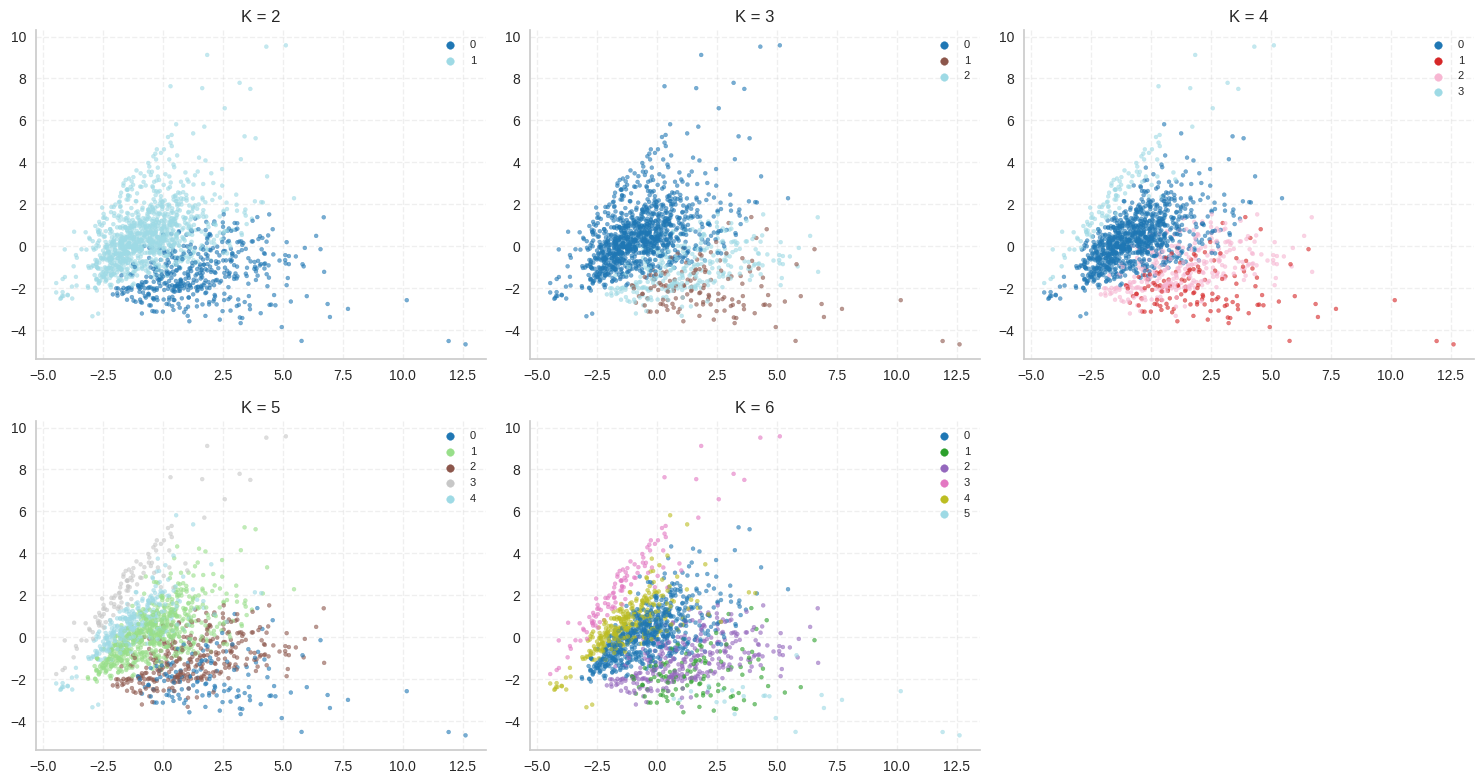

In [52]:
Ks = [2, 3, 4, 5, 6]

coords = pca.transform(data_num)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, K in enumerate(Ks):
    ac = AgglomerativeClustering(n_clusters=K, compute_distances=True, linkage="ward")
    clusters_ac = ac.fit_predict(data_num)

    ax = axes[idx]

    cmap = plt.get_cmap("tab20", K)
    colors = [cmap(i) for i in range(K)]

    ax.scatter(
        coords.iloc[:, 0],
        coords.iloc[:, 1],
        c=[colors[i] for i in clusters_ac],
        s=8,
        alpha=0.6
    )

    ax.set_title(f"K = {K}")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

    # légende légère
    for i in range(K):
        ax.scatter([], [], c=[colors[i]], label=str(i), s=30)
    ax.legend(fontsize=8, loc="best")

# si jamais grille pas pleine
for j in range(len(Ks), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

EST CE QUE CA VAUT LE COUP DE TRACER POUR PLS VALEURS DE K CAR AVEC WARD ON PEUT COUPER LE DENDROME A PLS ENDROITS.

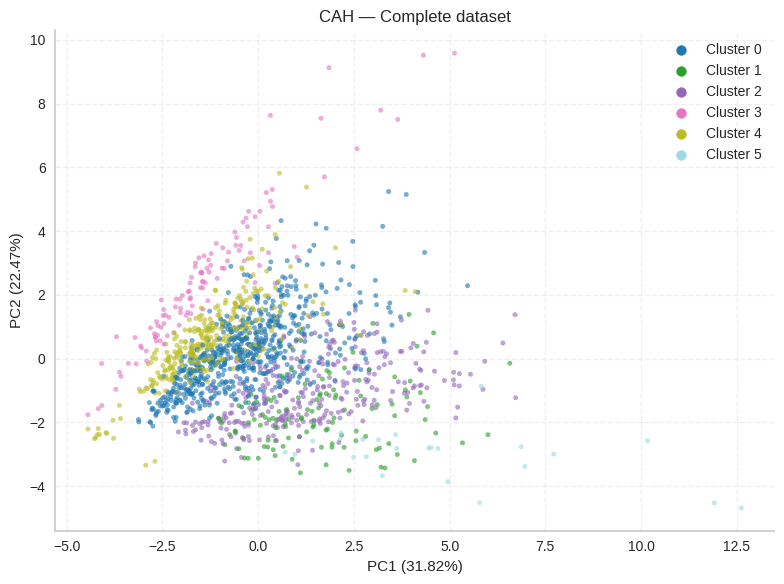

In [96]:
K = 6

ac = AgglomerativeClustering(n_clusters=K, compute_distances=True, linkage="ward")
clusters_ac = ac.fit_predict(data_num)

fig, ax = plt.subplots(figsize=(8, 6))

# PCA projection (si dispo)
coords = pca.transform(data_num)

cmap = plt.get_cmap("tab20", K)
colors = [cmap(i) for i in range(K)]
#colors = [plt.get_cmap("Set3", K)(i) for i in range(K)]   couleurs pastel

sc = ax.scatter(coords.iloc[:, 0], coords.iloc[:, 1],
                c=[colors[i] for i in clusters_ac],
                s=10, alpha=0.6)

ax.set_title("CAH — Complete dataset")
ax.set_xlabel(f"PC1 ({pca.eigenvalues_summary.loc[0, '% of variance']})")
ax.set_ylabel(f"PC2 ({pca.eigenvalues_summary.loc[1, '% of variance']})")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

# Legend (mieux que colorbar pour clusters)
for i in range(K):
    ax.scatter([], [], c=[colors[i]], label=f"Cluster {i}", s=50)

ax.legend()

plt.tight_layout()
plt.show()

# 3. Méthode des Spectral clustering

Les méthodes de clustering par approche spectrale reposent sur une représentation des données sous forme de graphe, où chaque point est un nœud et les arêtes représentent la similarité entre points. L’idée est de transformer le problème de clustering en une analyse des valeurs propres de la matrice appelée Laplacien du graphe. En projetant les données dans un espace de plus faible dimension basé sur ces valeurs propres, on rend les structures de clusters plus facilement séparables. Ensuite, un algorithme classique comme k-means est appliqué dans cet espace transformé pour identifier les groupes. Cette méthode est particulièrement efficace pour détecter des clusters non convexes ou de formes complexes.

In [72]:
from sklearn.cluster import SpectralClustering

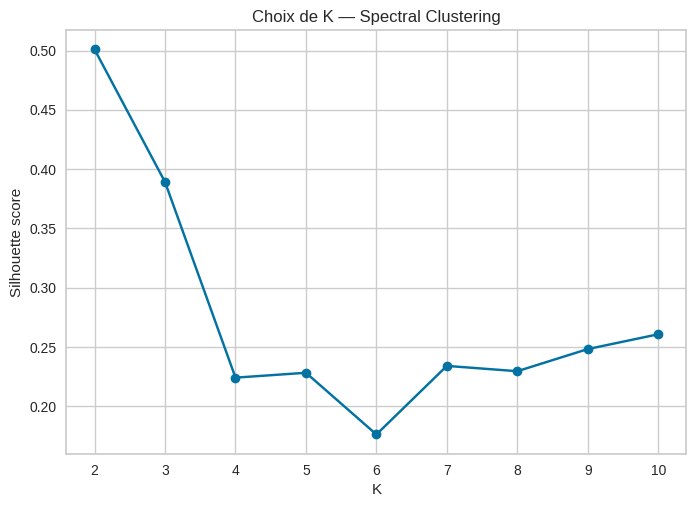

In [74]:
Ks = range(2, 11)
scores = []

for K in Ks:
    sc = SpectralClustering(n_clusters=K, affinity="nearest_neighbors", random_state=0)
    labels = sc.fit_predict(data_num)
    scores.append(silhouette_score(data_num, labels))

plt.plot(Ks, scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Choix de K — Spectral Clustering")
plt.show()

Le score silhouette nous indiquerai de choisir 4 ou 6 clusters.

In [168]:
K = 4  # ou 6

sc = SpectralClustering(
    n_clusters=K,
    affinity="nearest_neighbors",  # ou "rbf"
    assign_labels="kmeans",
    random_state=0
)

clusters_sc = sc.fit_predict(data_num)

fig, ax = plt.subplots(figsize=(8, 8))

cmap = plt.get_cmap("Set3", K)
colors = [cmap(i) for i in range(K)]

ax.scatter(coords.iloc[:, 0], coords.iloc[:, 1],
           c=[colors[i] for i in clusters_sc],
           s=10, alpha=1)

ax.set_title(f"Spectral Clustering — K = {K}")
ax.set_xlabel(f"PC1 ({pca.eigenvalues_summary.loc[0, '% of variance']})")
ax.set_ylabel(f"PC2 ({pca.eigenvalues_summary.loc[1, '% of variance']})")

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'SpectralClustering' is not defined

# 4. Méthode des Gaussian Mixture Models (GMM)

Les Gaussian Mixture Models (GMM) sont une méthode de clustering probabiliste qui suppose que les données proviennent d’un mélange de plusieurs distributions gaussiennes. Chaque point appartient à chaque cluster avec une certaine probabilité, plutôt que d’être assigné à un seul groupe. Les paramètres (moyenne, covariance, poids) de chaque gaussienne sont estimés avec l’algorithme Expectation-Maximization (EM). Cette méthode permet de détecter des clusters de formes variées, notamment non sphériques.

In [55]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score 

### Sélection du nombre de clusters

J'AI PAS VERIFIE LA NORMALISATION DES DONNEES

### 1. Critère BIC

Ce critère de sélection permet un bon compromis entre précision et simplicité du modèle.

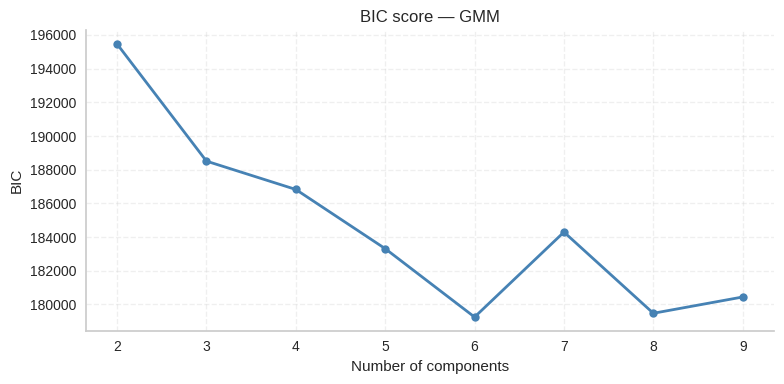

In [56]:
k_max = 10

bic = np.array([
    GaussianMixture(n_components=k, init_params="kmeans", n_init=3)
    .fit(data_num).bic(data_num)
    for k in range(2, k_max)
])


fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(2, k_max), bic, marker="o", color="steelblue",
        linewidth=2, markersize=6)
ax.set_xlabel("Number of components")
ax.set_ylabel("BIC")
ax.set_title("BIC score — GMM")
ax.set_xticks(range(2, k_max))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

On choisit le nombre de clusters qui minimise le BIC, ici 6 ou 8 clusters. Nous allons regarder un autre critère. 



### 2. Score silhouette

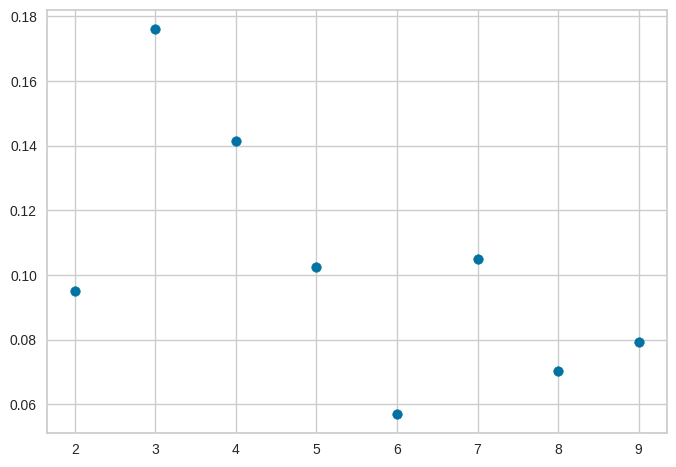

In [57]:
k_max = 10

silhouette = []
for k in range(2, k_max):
    gmm = GaussianMixture(n_components=k, init_params='kmeans', n_init=3)
    clusters_gmm = gmm.fit_predict(data_num)
    silhouette.append( silhouette_score(data_num, clusters_gmm, metric='euclidean') )
silhouette = np.array(silhouette)

plt.scatter(range(2, k_max), silhouette)
plt.show()

On choisit le nombre de clusters qui maximise le score silhouette. Ici, il est maximal pour 3 clusters.

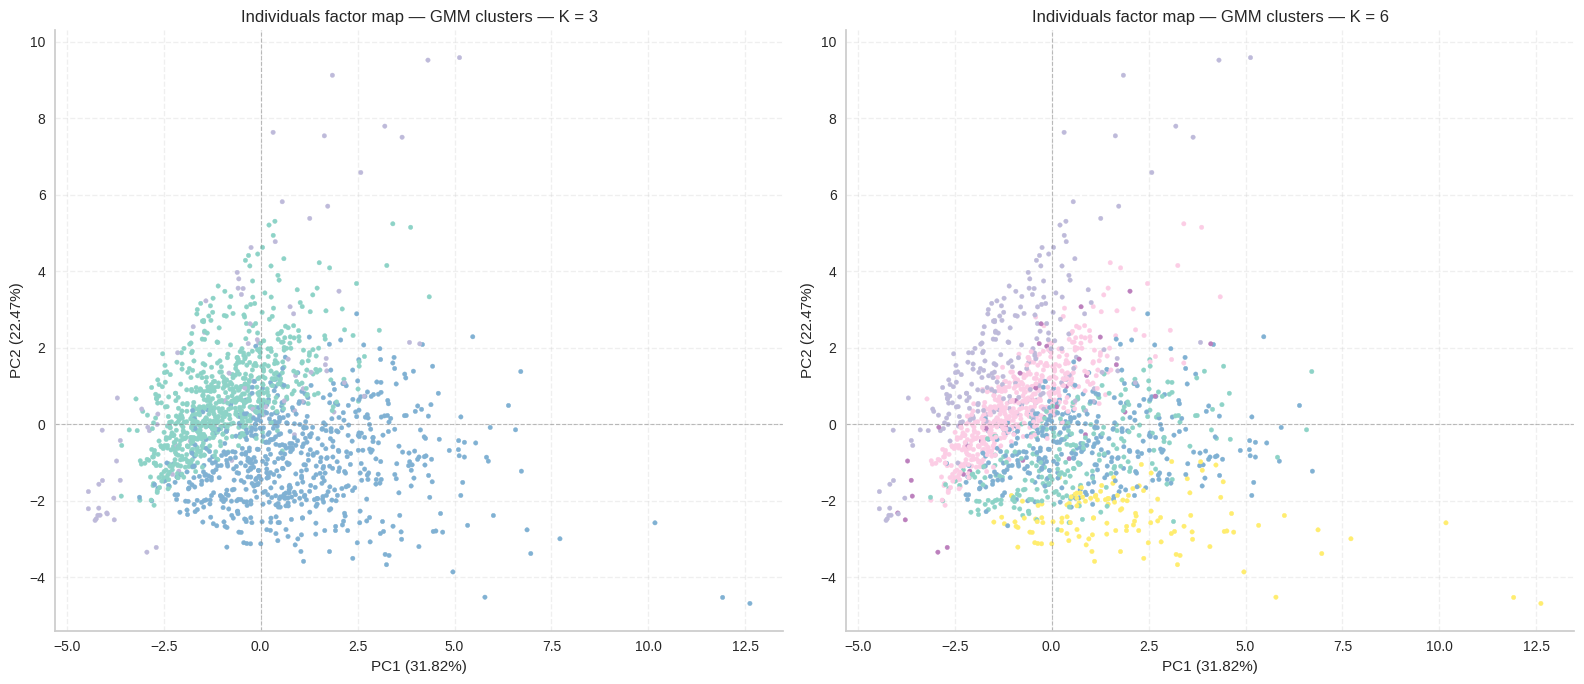

In [68]:
Ks = [3, 6]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, K in enumerate(Ks):

    cmap = plt.get_cmap("Set3", K)

    gmm = GaussianMixture(n_components=K, n_init=3)
    clusters_gmm = gmm.fit_predict(data_num)

    # tes couleurs (inchangées dans l'esprit)
#    colors = [cmap(i) for i in range(K)]

    ax = axes[idx]

    sc = ax.scatter(coords.iloc[:, 0], coords.iloc[:, 1],
                    c=[colors[i] for i in clusters_gmm],
                    s=10, alpha=1)

    ax.set_title(f"Individuals factor map — GMM clusters — K = {K}")

    ax.set_xlabel(f"PC1 ({pca.eigenvalues_summary.loc[0, '% of variance']})")
    ax.set_ylabel(f"PC2 ({pca.eigenvalues_summary.loc[1, '% of variance']})")

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Ces critères ne nous permettent pas de choisir un nombre de clusters optimal.

SyntaxError: invalid syntax (1635001939.py, line 1)

# 5. Méthode des Stochastic Bloc Model (SBM)

Le Stochastic Block Model (SBM) est une méthode de clustering pour données sous forme de graphe.
Il suppose que les nœuds appartiennent à des groupes cachés, et que la probabilité de connexion entre deux nœuds dépend uniquement de leurs groupes.

In [76]:
from graph_tool.all import * # j'ai pas installé ca donc jsp si ca marche mais je suis pas sure que ca soit pertinent de le faire
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'graph_tool'

In [ ]:
# G : ton graphe (à construire à partir de data_num ou matrice d'adjacence)

BIC_scores = []
Ks = range(2, 11)

for K in Ks:
    state = minimize_blockmodel_dl(G, B=K)  # SBM fitting
    BIC_scores.append(state.entropy())      # approx BIC (DL = description length)

plt.plot(Ks, BIC_scores, marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Description length (≈ BIC)")
plt.title("SBM model selection")
plt.show()

In [ ]:
K_opt = Ks[np.argmin(BIC_scores)]

state = minimize_blockmodel_dl(G, B=K_opt)

clusters_sbm = state.get_blocks().get_array()

print(clusters_sbm)

Nous avons donc testé plusieurs méthodes de clustering, ne nous révélant pas de nombre de clustering évident. En prenant 2, puis 3 et 6 clusters, nous allons regarder les moyennes et proportions des variables au sein de chque groupe pour voir si on observe des caractéristiques communes, ie si les groupes ont un sens concret.

In [166]:
# AVANT DE FAIRE TOURENER : Décommenter la ligne de la méthode à utiliser et modifier le le nombre de cluster K

K=2

#clusters = kmeans_pca.fit_predict(df_pca) #kmeans
#clusters = ac.fit_predict(data_num) #hac
clusters = sc.fit_predict(data_num) #spectral clustering
#clusters = gmm.fit_predict(data_num) #gmm
#clusters = state.get_blocks().get_array() #sbm

# Ajout des labels au dataframe original
data['Cluster'] = clusters_pca

# Variables quantitatives : moyennes
cols_quant = data.select_dtypes(include=['number']).columns
moyennes_par_cluster = data.groupby('Cluster')[cols_quant].mean()

# Variables qualitatives : proportions
cols_qual = data.select_dtypes(include=['object', 'category']).columns
proportions_par_cluster = {}

for col in cols_qual:
    # crosstab donne les lignes par cluster et les colonnes par modalité
    prop = pd.crosstab(data['Cluster'], data[col], normalize='index')
    proportions_par_cluster[col] = prop

# Affichage
print("Moyennes (Quantitatives)")
print(moyennes_par_cluster)

NameError: name 'sc' is not defined

JE PENSE QUE C'EST INUTILE EN VRAI

Les résultats avec K=2 et K=4 sont identiques. La plus forte proportion de trains en retard dans le cluster 1 s'explique simplement par le fait qu'il contient plus de trains au total. Les moyennes restent identiques entre les groupes, ce qui confirme que l'intensité du retard n'est pas différente.

Pour K=6, aucune variable qualitative ne montre de particularité et elles sont toutes réparties de manière uniforme
. Les causes de retard et la moyenne de retard des trains en retard restent également homogènes quel que soit le nombre de clusters choisi

. En résumé, le clustering ne permet pas de distinguer des profils de trains spécifiques car les données sont uniformément réparties.

In [162]:
print("\n=== Proportions (Variables Qualitatives) ===")

for col in cols_qual:
    # Calcul des proportions pour la colonne courante
    proportions = pd.crosstab(data['Cluster'], data[col], normalize='index')
    
    print(f"\n--- Variable : {col} ---")
    # Affichage du DataFrame des proportions
    print(proportions)


=== Proportions (Variables Qualitatives) ===

--- Variable : date ---
date      2025-01   2025-02   2025-03   2025-04   2025-05   2025-06   2025-07  \
Cluster                                                                         
0        0.077570  0.080374  0.077570  0.081308  0.082243  0.081308  0.093458   
1        0.087356  0.080460  0.087356  0.085057  0.080460  0.085057  0.080460   

date      2025-08   2025-09   2025-10   2025-11   2025-12  
Cluster                                                    
0        0.092523  0.092523  0.079439  0.082243  0.079439  
1        0.082759  0.082759  0.082759  0.080460  0.085057  

--- Variable : service ---
service  International  National
Cluster                         
0             0.190654  0.809346
1             0.000000  1.000000

--- Variable : dep_station ---
dep_station         0  AIX EN PROVENCE TGV  ANGERS SAINT LAUD  ANGOULEME  \
Cluster                                                                    
0            0.00280

JE PENSE QUE C'EST INUTILE EN VRAI

Pour K=2 et K=4, les dates sont uniformément réparties. La variable retard ne montre pas de lien avec les clusters car ses modalités sont mélangées. C'est pareil pour le service entre National et International. Les gares de départ ou d'arrivée apparaissent souvent dans un seul cluster mais cela ne permet pas d'interprétation claire.

Pour K=6, les dates restent uniformes. La modalité International est présente dans deux clusters mais mélangée avec National, ce qui ne permet pas de distinguer un profil. Les gares sont aussi dispersées sur un ou deux clusters sans logique évidente. Le retard reste de nouveau réparti sans séparation claire entre les groupes

. En résumé, le clustering ne permet pas de dégager de profils significatifs sur ces variables. 

ON POURRAIT LAISSER JUSTE CETTE PHRASE
Nous avons testé K-means, Agglomératif et GMM. Toutes les méthodes confirment l'absence de regroupements significatifs.

# Clustering sur la MCA

A FAIRE J'AI A PEINE COMMENCE

In [5]:
# from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

X_mca = mca.row_coordinates()
X_clustering = X_mca.iloc[:, :3] # On sélectionne uniquement les premiers axes (cf MCA)

NameError: name 'mca' is not defined

In [7]:
X_mca = mca.transform(data_qual) 
X_clustering = X_mca.iloc[:, :3]

NameError: name 'mca' is not defined

###  Méthode du Coude

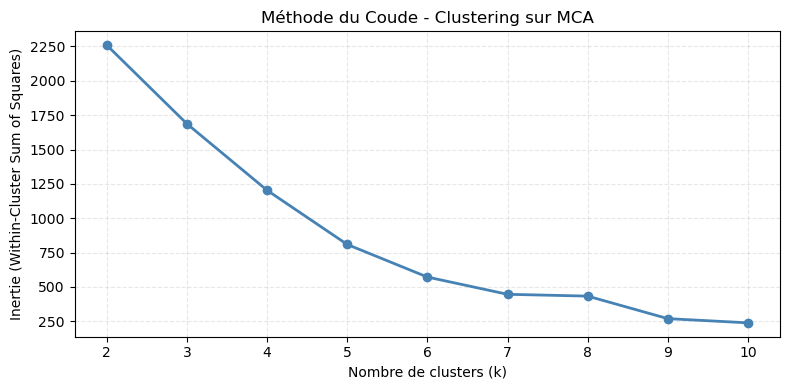

NameError: name 'KElbowVisualizer' is not defined

In [87]:
inertia = []
k_values = range(2, 11) # Teste de 2 à 10 clusters

for k in k_values:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto",
                    max_iter=100, random_state=42)
    kmeans.fit(X_clustering)
    inertia.append(kmeans.inertia_)

inertia = np.array(inertia)

# Affichage du graphique
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, inertia, marker="o", color="steelblue", linewidth=2, markersize=6)
ax.set_xlabel("Nombre de clusters (k)")
ax.set_ylabel("Inertie (Within-Cluster Sum of Squares)")
ax.set_title("Méthode du Coude - Clustering sur MCA")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

kmeans = KMeans(init='k-means++', n_init='auto', max_iter=100, random_state=42)
# k=(min, max) pour la recherche
visualizer_elbow = KElbowVisualizer(kmeans, k=(2, 10), force_model=True)

visualizer_elbow.fit(X_clustering)
visualizer_elbow.show()

### Silhouette 

NameError: name 'SilhouetteVisualizer' is not defined

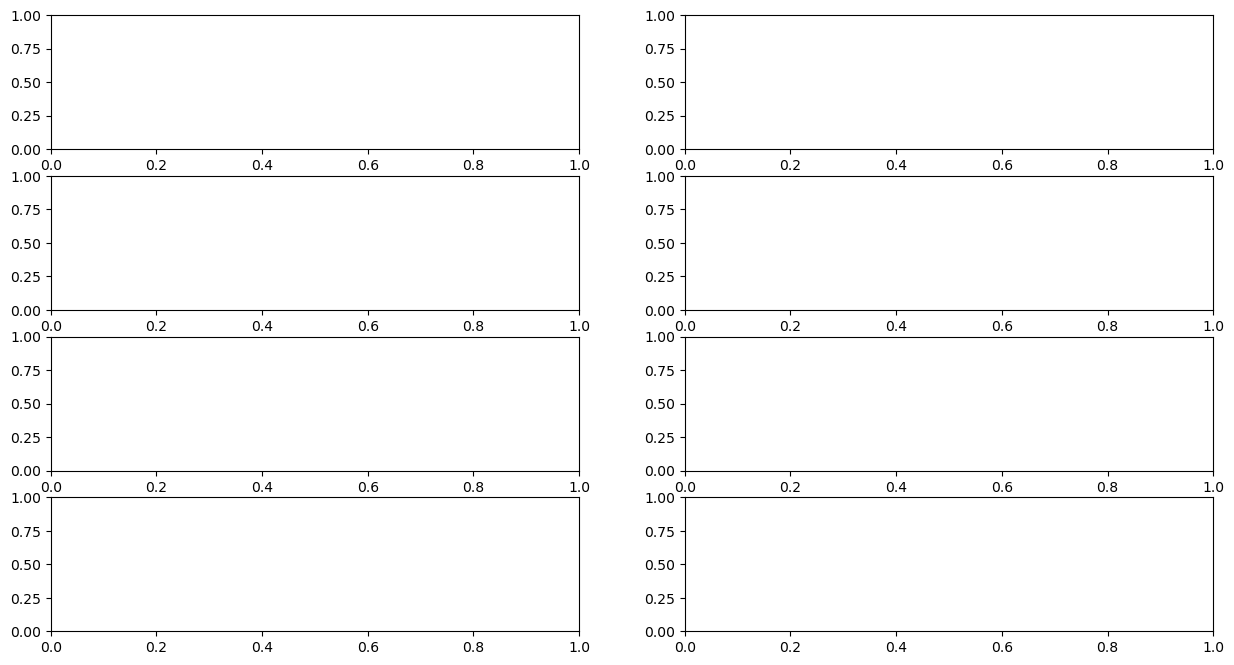

In [89]:
fig, ax = plt.subplots(4, 2, figsize=(15, 8))

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=100, random_state=42)
    q, mod = divmod(k, 2) # Pour placer les graphiques dans la grille 4x2
    
    # Création du visualiseur Silhouette
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax[q][mod], force_model=True)
    visualizer.fit(X_clustering)
    # visualizer.show() # On n'affiche pas ici car on les met tous dans la même figure

plt.suptitle("Scores de Silhouette pour différents k (sur coordonnées MCA)", y=1.02)
plt.tight_layout()
plt.show()

# Comparison of clustering algorithms

C'ETAIT FAIT DANS LE TP MAIS FRANCHEMENT JE SAIS PAS A QUOI CA SERT

Avec les différentes méthodes de clustering testées, on observe de manière cohérente qu’aucune structure de clusters clairement séparés ne se dégage dans l’ensemble des données. Les partitions obtenues sont globalement similaires d’une méthode à l’autre, mais restent peu nettes, avec un fort chevauchement entre les groupes. De plus, les critères de sélection du nombre optimal de clusters varient selon les approches, ce qui confirme l’absence d’une structure naturelle fortement marquée dans les données.

In [104]:
from scipy.spatial.distance import cdist
from matplotlib.patches import Ellipse

### Kmeans versus GMM components

array([0, 4, 3, ..., 1, 5, 4], shape=(1505,), dtype=int32)

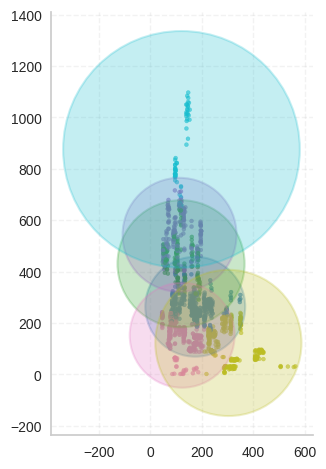

In [123]:
def plotKmeans(kmeans, data, n_clusters=6):
    """
    Plot K-means clustering with circles representing each cluster's extent.
    """

    # Fit + predict
    kmeans.fit(data)
    clusters = kmeans.predict(data)
    centers = kmeans.cluster_centers_

    cmap = plt.get_cmap("tab10", n_clusters)
    ax = plt.gca()

    # Scatter (FIX pandas → numpy safe)
    X = data.values if hasattr(data, "values") else data

    ax.scatter(X[:, 0], X[:, 1],
               c=clusters, s=8, alpha=0.6,
               cmap=cmap)

    # Cluster radii
    radii = [
        cdist(X[clusters == i], [center]).max()
        for i, center in enumerate(centers)
    ]

    # Circles
    for i, (center, radius) in enumerate(zip(centers, radii)):
        ax.add_patch(plt.Circle(center, radius,
                                facecolor=cmap.colors[i], edgecolor=cmap.colors[i],
                                alpha=0.25, linewidth=1.5))
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

    return clusters

K = 6
kmeans = KMeans(n_clusters=K)

plotKmeans(kmeans, data_num)

On pourrait faire clustering sur seulement une partie des données pour essayer de répondre à des questions précises cf TP velib

# Réduction de dimension non-linéaire